In [1]:
# Importing libraries and reading csv file
import pandas as pd

churn_df = pd.read_csv('csv_files/churn_data.csv')
churn_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [2]:
churn_df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [3]:
churn_df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

##### What does it mean for a customer to churn?
- Customer churn means the rate of customers stopping to do business with a company over a time period.

##### Why does a bank care about this?
- Because losing a customer means sacrificing long-term interest income, account fees, and cross-selling opportunities.

##### What might cause a customer to leave?
- Poor customer service, high or hidden fees, and the lure of better competitor rates

In [4]:
# Droppping irrelevant columns
relevant_df =churn_df.drop(columns = ['CustomerId', 'Surname'])
relevant_df.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [5]:
# Checking for duplicates

relevant_df.duplicated().sum()

np.int64(0)

In [6]:
# Creating bins for ages.
# The Age column is a continuous number, but for analysis it is more useful to group customers into brackets.

bins=[0, 30, 40, 50, 60, 100]
labels=['18-30', '31-40', '41-50', '51-60', '60+']

relevant_df['Age_Group'] = pd.cut(relevant_df['Age'], bins=bins, labels=labels, right=False)

relevant_df['Age_Group'].head()

0    41-50
1    41-50
2    41-50
3    31-40
4    41-50
Name: Age_Group, dtype: category
Categories (5, str): ['18-30' < '31-40' < '41-50' < '51-60' < '60+']

In [7]:
# Creating bins for balance.
bins = [0, 1,80000,160000, float('inf')]
labels = ['Zero Balance', 'Low', 'Medium', 'High']

relevant_df['Balance_Group'] = pd.cut(relevant_df['Balance'], bins= bins, labels= labels, include_lowest=True  )
relevant_df['Balance_Group'].head()

0    Zero Balance
1          Medium
2          Medium
3    Zero Balance
4          Medium
Name: Balance_Group, dtype: category
Categories (4, str): ['Zero Balance' < 'Low' < 'Medium' < 'High']

In [8]:
relevant_df['Age_Group'].value_counts()

Age_Group
31-40    4346
41-50    2618
18-30    1641
51-60     869
60+       526
Name: count, dtype: int64

In [9]:
# Label encoding gender
from sklearn.preprocessing import LabelEncoder

In [10]:
le_gender = LabelEncoder()
relevant_df['Gender'] = le_gender.fit_transform(relevant_df['Gender'])

In [11]:
print(relevant_df['Gender'].unique())

# Female- 0
# Male - 1

[0 1]


In [12]:
relevant_df.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Age_Group,Balance_Group
0,1,619,France,0,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,41-50,Zero Balance
1,2,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,41-50,Medium
2,3,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,41-50,Medium
3,4,699,France,0,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,31-40,Zero Balance
4,5,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,41-50,Medium


#### Exploratory data analysis

##### Uncovering churn patterns across every key variable

##### 1. Calaulating the overall churn rate 

Formula = (total churned / total customers) * 100

In [13]:
relevant_df['Churn'] = relevant_df['Exited']
relevant_df.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Age_Group,Balance_Group,Churn
0,1,619,France,0,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,41-50,Zero Balance,1
1,2,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,41-50,Medium,0
2,3,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,41-50,Medium,1
3,4,699,France,0,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,31-40,Zero Balance,0
4,5,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,41-50,Medium,0


In [14]:
# Overall churn rate
total_customer= len(relevant_df)
total_churned = relevant_df['Churn'].sum()
overall_churn_rate = (total_churned / total_customer) * 100

print(f"  Total Customers : {total_customer}")
print(f"  Total Churned   : {total_churned}")
print(f"  Churn Rate      : {overall_churn_rate:.2f}%\n")

  Total Customers : 10000
  Total Churned   : 2038
  Churn Rate      : 20.38%



#####  2. Calculating churn rate by geography

In [15]:
# Creating a function that calculates the churn rate of required columns

def churn_summary(df, col):
    group = df.groupby(col).agg(
         Total = ('Churn', 'count'),
        Churned = ('Churn', 'sum')
    ).reset_index()

    group['churn_rate_%'] = (group['Churned'] / group['Total'])  * 100

    return group

In [16]:
geo_summary = churn_summary(relevant_df, 'Geography')

print('Churn rate by geography:')
print('-' * 50)
print(geo_summary.to_string(index= False))

Churn rate by geography:
--------------------------------------------------
Geography  Total  Churned  churn_rate_%
   France   5014      811     16.174711
  Germany   2509      814     32.443204
    Spain   2477      413     16.673395


##### 3. Calculating churn rate by gender

In [17]:
gender_summary = churn_summary(relevant_df, 'Gender')

print('Churn rate by gender:')
print('-' * 50)
print(gender_summary.to_string(index= False))

Churn rate by gender:
--------------------------------------------------
 Gender  Total  Churned  churn_rate_%
      0   4543     1139     25.071539
      1   5457      899     16.474253


##### 4. Calculating churn rate by AgeGroup

In [18]:
age_summary = churn_summary(relevant_df, 'Age_Group')

print('Churn rate by Age Group:')
print('-' * 50)
print(age_summary.to_string(index= False))

Churn rate by Age Group:
--------------------------------------------------
Age_Group  Total  Churned  churn_rate_%
    18-30   1641      124      7.556368
    31-40   4346      473     10.883571
    41-50   2618      807     30.825057
    51-60    869      487     56.041427
      60+    526      147     27.946768


##### 5. Calclating churn rate by Number of products

In [19]:
product_summary = churn_summary(relevant_df, 'NumOfProducts')

print('Churn rate by Number of producst:')
print('-' * 50)
print(product_summary.to_string(index= False))

Churn rate by Number of producst:
--------------------------------------------------
 NumOfProducts  Total  Churned  churn_rate_%
             1   5084     1409     27.714398
             2   4590      349      7.603486
             3    266      220     82.706767
             4     60       60    100.000000


##### 6. Calculating churn rate by Active Member Status

In [20]:
## relevant_df['ActiveStatus'] = relevant_df['IsActiveMember'].map({1: 'Active', 0: 'Inactive'})
member_status_summary = churn_summary(relevant_df, 'IsActiveMember')

print('Churn rate by Active member status: ')
print('-' * 50)
print(member_status_summary.to_string(index= False))

Churn rate by Active member status: 
--------------------------------------------------
 IsActiveMember  Total  Churned  churn_rate_%
              0   4849     1303     26.871520
              1   5151      735     14.269074


#### Analyzing numerical features and correlations

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt


##### Checking distribution of Numerical Features by Churn Status

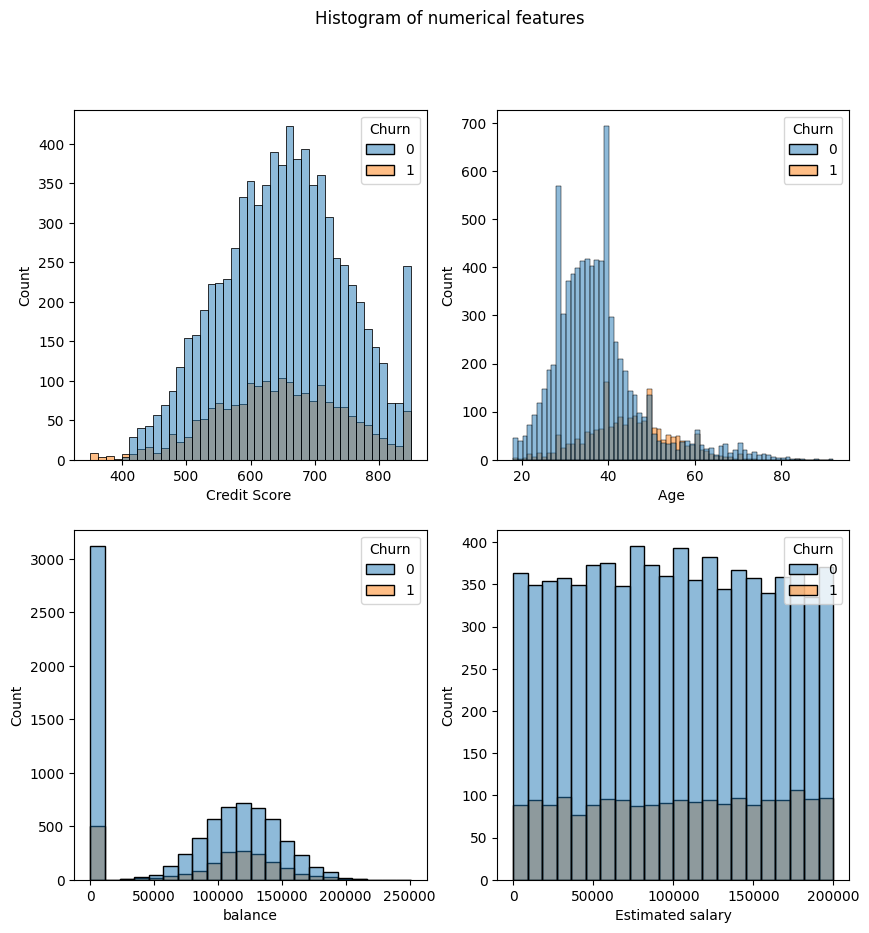

In [22]:
# Histogram

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
sns.histplot(data =relevant_df, x='CreditScore', ax=ax[0,0], hue='Churn')
sns.histplot(data =relevant_df, x='Age', ax=ax[0,1], hue='Churn')
sns.histplot(data =relevant_df, x='Balance', ax=ax[1,0], hue='Churn')
sns.histplot(data =relevant_df, x='EstimatedSalary', ax=ax[1,1], hue='Churn')

fig.suptitle('Histogram of numerical features')
ax[0,0].xaxis.set_label_text("Credit Score ")
ax[0,1].xaxis.set_label_text("Age ")
ax[1,0].xaxis.set_label_text("balance")
ax[1,1].xaxis.set_label_text("Estimated salary")
plt.show()

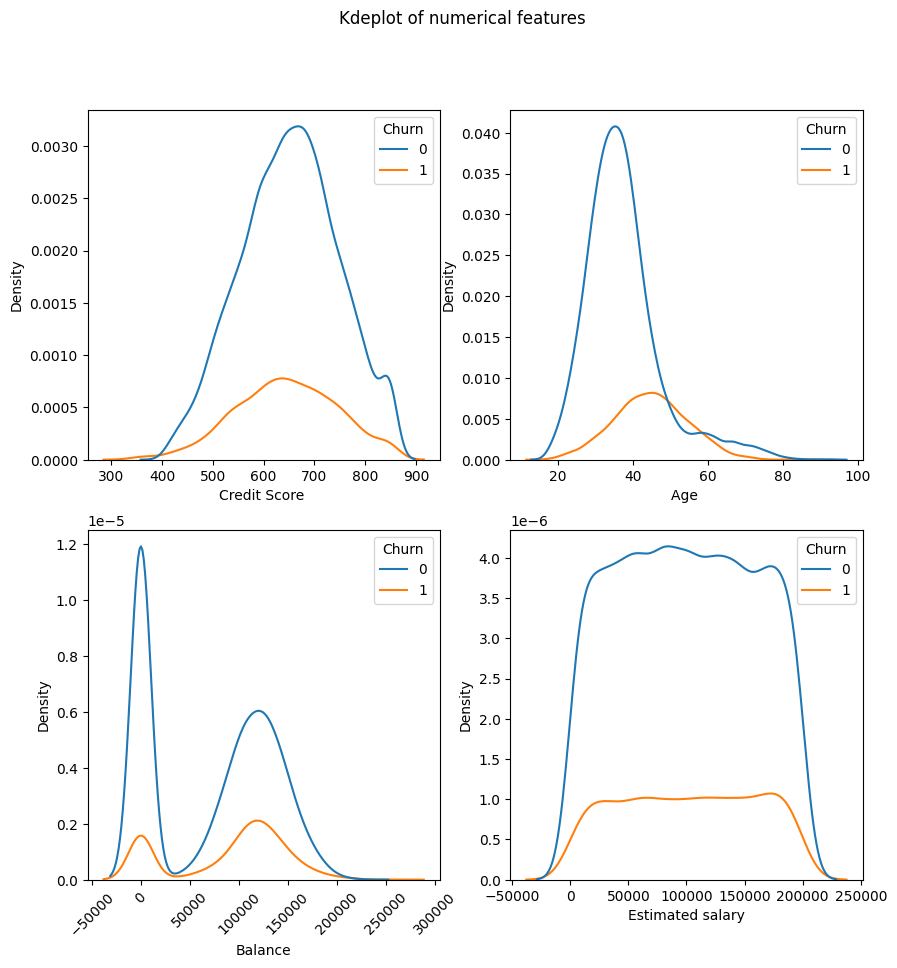

In [23]:
# kdeplot(Kernel Density Estimate plot) 

fig_2, ax_2= plt.subplots(2, 2, figsize=(10, 10))

sns.kdeplot(data=relevant_df, x='CreditScore', y=None, hue='Churn', fill= False, ax= ax_2[0,0])
sns.kdeplot(data=relevant_df, x='Age', y=None, hue='Churn', fill= False, ax= ax_2[0,1])
sns.kdeplot(data=relevant_df, x='Balance', y=None, hue='Churn', fill= False, ax= ax_2[1,0])
sns.kdeplot(data=relevant_df, x='EstimatedSalary', y=None, hue='Churn', fill= False, ax=ax_2[1,1])

fig_2.suptitle('Kdeplot of numerical features')
ax_2[0,0].xaxis.set_label_text("Credit Score ")
ax_2[0,1].xaxis.set_label_text("Age ")
ax_2[1,0].xaxis.set_label_text("Balance")
ax_2[1,1].xaxis.set_label_text("Estimated salary")

ax_2[1,0].tick_params(axis='x', rotation=45)
plt.show()

#### Correlation Heatmap

<Axes: >

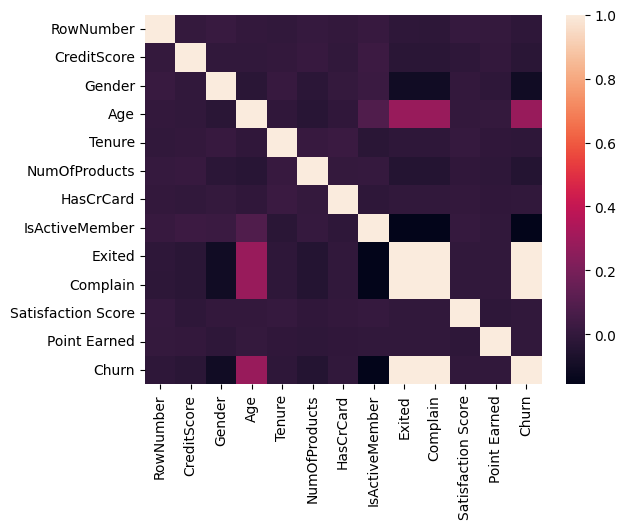

In [24]:
corr_calculation= relevant_df.select_dtypes(int).corr()
sns.heatmap(corr_calculation)

#### Box Plots for Numerical Features by Churn

<Axes: xlabel='Churn', ylabel='CreditScore'>

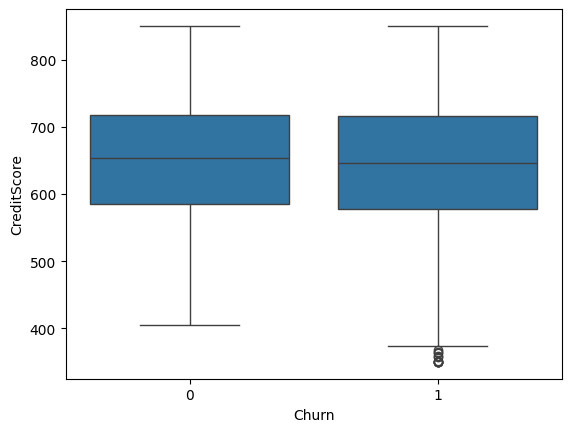

In [25]:
sns.boxplot(x='Churn', y='CreditScore', data=relevant_df)

<Axes: xlabel='Churn', ylabel='Age'>

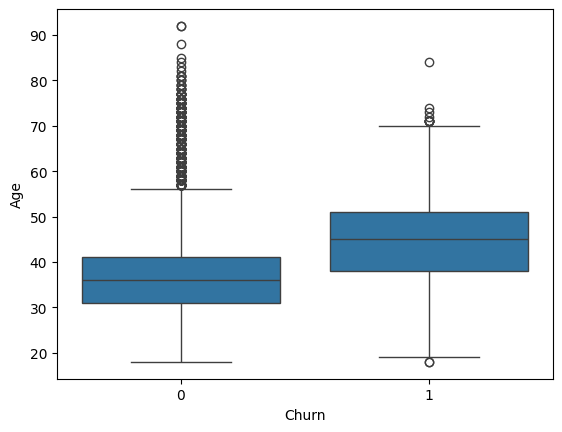

In [26]:
sns.boxplot(x='Churn', y='Age', data=relevant_df)

<Axes: xlabel='Churn', ylabel='Balance'>

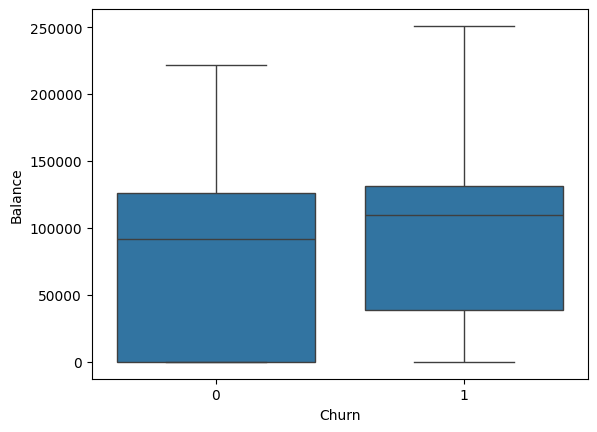

In [27]:
sns.boxplot(x='Churn', y='Balance', data=relevant_df)